In [31]:
from dotenv import load_dotenv
import os
load_dotenv()

if os.getenv("GROQ_API_KEY") is None:
    raise ValueError("GROQ_API_KEY is not set")
else:
    print("GROQ_API_KEY is set")

GROQ_API_KEY is set


In [32]:
from langchain_groq import ChatGroq

llm = ChatGroq(
    model_name="llama-3.3-70b-versatile",
    api_key=os.getenv("GROQ_API_KEY"),
)
llm

ChatGroq(profile={'max_input_tokens': 131072, 'max_output_tokens': 32768, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': False, 'tool_calling': True}, client=<groq.resources.chat.completions.Completions object at 0x7fdd5c0a3110>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x7fdd5c0a3b10>, model_name='llama-3.3-70b-versatile', model_kwargs={}, groq_api_key=SecretStr('**********'))

## **Generator - Evaluator**
### In this we have one generator node, which generates the response and one evaluate node, which evaluates the response. If the response is not correct, then the evaluator passes the response to generator node and asks to regenerate the response.
### This continues till a loop. we can define the condition when we want to stop the loop.

## Pydantic llm schema

In [33]:
from pydantic import BaseModel, Field
from typing import List, TypedDict, Literal

class llm_schema(BaseModel):
    funny_flag: Literal["funny", "not_funny"] = Field(description="Whether the joke is funny or not")
    feedback: str = Field(description="Feedback on the joke")

llm_with_schema = llm.with_structured_output(llm_schema)

In [34]:
llm_with_schema.invoke("Elephants are big and grey")


llm_schema(funny_flag='not_funny', feedback='The statement is factual but lacks any humorous element.')

## Graph schema

In [35]:
class GraphSchema(TypedDict):
    topic: str
    joke: str
    funny_flag: str
    feedback: str
    retry_count: int
    max_retries: int

## Graph



In [36]:
## Nodes

In [37]:
def generate_node(state: GraphSchema) -> GraphSchema:
    topic = state["topic"]
    feedback = state.get("feedback", "")

    if feedback:
        response = llm.invoke(
            f"Improve this joke about {topic}: {state.get('joke', '')}. "
            f"Use this feedback: {feedback}"
        )
    else:
        response = llm.invoke(f"Generate a short funny joke about {topic}.")

    return {"joke": response.content}

In [38]:
from langchain_core.prompts import ChatPromptTemplate


def evaluate_node(state: GraphSchema) -> GraphSchema:
    joke = state["joke"]
    retry_count = state.get("retry_count", 0)

    prompt = ChatPromptTemplate.from_messages(
        [
            (
                "system",
                "You are a comedy critic. Evaluate jokes and provide concise feedback.",
            ),
            (
                "human",
                "Evaluate this joke: {joke}. Return `funny_flag` as either `funny` or `not_funny`. "
                "If `not_funny`, provide short actionable feedback.",
            ),
        ]
    )

    chain = prompt | llm_with_schema
    response = chain.invoke({"joke": joke})

    return {
        "funny_flag": response.funny_flag,
        "feedback": response.feedback,
        "retry_count": retry_count + 1,
    }

In [39]:
## conditional edge function

In [40]:
def check_iteration(state: GraphSchema) -> str:
    retry_count = state.get("retry_count", 0)
    max_retries = state["max_retries"]

    if state["funny_flag"] == "not_funny" and retry_count < max_retries:
        return "generate"
    else:
        return "end"



In [41]:
## create state graph

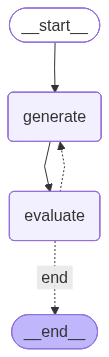

In [42]:
from langgraph.graph import StateGraph, START, END

graph = StateGraph(GraphSchema)

graph.add_node("generate", generate_node)
graph.add_node("evaluate", evaluate_node)

graph.add_edge(START, "generate")
graph.add_edge("generate", "evaluate")
graph.add_conditional_edges("evaluate", check_iteration, {"generate": "generate", "end": END})

evaluator_graph = graph.compile()

## view the graph
from IPython.display import Image, display
Image(evaluator_graph.get_graph().draw_mermaid_png())

In [43]:
## Invoke the graph

In [49]:
for chunk in evaluator_graph.stream(
    {"topic": "school", "max_retries": 3, "retry_count": 0},
    stream_mode="updates",
):
    print(chunk)


{'generate': {'joke': 'Why did the math book look so sad in school? Because it had too many problems.'}}
{'evaluate': {'funny_flag': 'funny', 'feedback': "The joke relies on a common play on words, using 'problems' to refer to both math exercises and personal issues, making it a classic and well-structured joke.", 'retry_count': 1}}


In [51]:
## Let;s choose a topic where retries also work
for chunk in evaluator_graph.stream(
    {"topic": "Eat", "max_retries": 3, "retry_count": 0},
    stream_mode="updates",
):
    print(chunk)




{'generate': {'joke': 'Why was the eatery\'s food in therapy? Because it was feeling a little "consumed" by its problems.'}}
{'evaluate': {'funny_flag': 'funny', 'feedback': "The joke is funny because it uses a clever play on words with 'consumed'.", 'retry_count': 1}}
